# Data transformations

In this document we will examine how the models transform the data, before proceeding to the multiclass classification task. The models that under evaluation are a Transformer and a LSTM. For the data visualization, t-SNE and UMAP will be used followed by their results comparison.

## Dataset and tools loading
Loading the required libraries and datasets needed to train and test the models.

In [72]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from torcheval.metrics import MulticlassAccuracy
import sys
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils import dataset_utils
from utils import train_test_utils as ttutils
from utils.models import MyTransformerModel, MyLSTMClassifier

from IPython.utils.io import capture_output

print(sys.path)

def load_config(file_path):
    with open(file_path, "r") as file:
        json_data = json.load(file)
        config = json_data["config"]
    return config

dataset_file = "/mnt/btrfs/datasets/cybersecurity/multiclass/cybersecurity-unified-multiclass.csv"
dataset_name = os.path.basename(dataset_file).split(".")[0]
lstm_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}.pt")
lstm_removed_sep_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}_sep_removed.pt")
lstm_removed_uni_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}_uni_removed.pt")
transformer_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}.pt")
transformer_sep_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}_sep_removed.pt")
transformer_uni_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}_uni_removed.pt")

rows_limit = 250e+3
chunk_size = 3e+6
DEVICE = ttutils.get_device()
TRANSFORMER_EPOCHS = 45
LSTM_EPOCHS = 10

with capture_output():
    csv_dataset = dataset_utils.CSVDataset(dataset_file, "Label", columns_to_drop=["Timestamp"], chunk_size=chunk_size)
    csv_dataset.load(rows_limit=rows_limit)

features, category_map, n_classes = csv_dataset.features, csv_dataset.categories, csv_dataset.n_classes
dataset_df = pd.DataFrame(csv_dataset.X.numpy(), columns=csv_dataset.features, dtype="float32")
dataset_df["Label"] = csv_dataset.y.numpy()
y = csv_dataset.y
X = csv_dataset.X
del csv_dataset

dataset_lstm_removed_df = dataset_df.drop(columns=["Fwd Seg Size Min", "Label"])
dataset_transformer_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Idle Mean", "Idle Min", "Idle Max", "Label"])
dataset_unified_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Fwd Seg Size Min", "Init Bwd Win Byts",
                                                        "Idle Mean", "Idle Min", "Idle Max", "Label"])

X_lstm_removed = torch.from_numpy(dataset_lstm_removed_df.to_numpy(dtype="float32"))
X_transformer_removed = torch.from_numpy(dataset_transformer_removed_df.to_numpy(dtype="float32"))
X_unified_removed = torch.from_numpy(dataset_unified_removed_df.to_numpy(dtype="float32"))
del dataset_lstm_removed_df, dataset_transformer_removed_df, dataset_unified_removed_df

print(category_map)
print(X.shape, X_lstm_removed.shape, X_transformer_removed.shape, X_unified_removed.shape)

dataset = TensorDataset(X,y)
dataset_lstm_removed = TensorDataset(X_lstm_removed, y)
dataset_transformer_removed = TensorDataset(X_transformer_removed, y)
dataset_unified_removed = TensorDataset(X_unified_removed, y)

del X, X_lstm_removed, X_transformer_removed, X_unified_removed, y
dataset_df


['/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/ray/thirdparty_files', '/usr/lib64/python313.zip', '/usr/lib64/python3.13', '/usr/lib64/python3.13/lib-dynload', '', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages', '/tmp/tmpb6he3bne', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis']
CUDA available! GPU device name is: NVIDIA GeForce RTX 4060
{0: 'Botnet', 1: 'DoS', 2: 'MITM', 3: 'Normal', 4: 'Scanner', 5: 'Brute force', 6: 'Generic', 7: 'Exploit', 8: 'Infection'}
torch.Size([150903, 81]) torch.Size([150903, 80]) torch.Size([150903, 76]) torch.Size([150903, 74])


,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3.232261e+09,17832.0,6.933821e+08,37215.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
1,3.232261e+09,17832.0,7.029892e+08,37215.0,6.0,5.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
2,3.232261e+09,17832.0,3.314032e+09,37215.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
3,3.232261e+09,17832.0,3.309613e+09,37215.0,6.0,5.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
4,3.232261e+09,17832.0,2.629541e+09,37215.0,6.0,4.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150898,3.119782e+09,4975.0,3.119782e+09,50516.0,6.0,500.0,1.0,1.0,26.0,25.0,...,32.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,8
150899,3.119782e+09,4975.0,3.232236e+09,52402.0,6.0,249.0,1.0,1.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,8
150900,2.261863e+09,4554.0,3.232236e+09,51650.0,6.0,1238.0,3.0,3.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,1.551397e+15,421.476379,1.551397e+15,1.551397e+15,8
150901,2.261863e+09,4554.0,3.232236e+09,52828.0,6.0,1240.0,3.0,3.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,1.551409e+15,425.232880,1.551409e+15,1.551409e+15,8


## Training models and data transformation

In order to visualize the data transformation of the best model, we need to train the model first on the 90% of the dataset. The rest 10% will be used for visualization needs.

### Training
#### Transformer

In [ ]:
transformer_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_transformer", "best_config_multiclass.json")
config = load_config(transformer_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
transformer_hyperparameters = config
enc_embed_dim = config["enc_embedding_dim"]
transformer_model = MyTransformerModel(dataset.tensors[0].shape[1], n_classes, **transformer_hyperparameters)

transformer_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_transformer", "improved_removed_features_best_config.json")
config = load_config(transformer_removed_config_file)
learning_removed_rate = config.pop("lr")
batch_removed_size = config.pop("batch_size")
transformer_removed_hyperparameters = config
enc_embed_dim_removed = config["enc_embedding_dim"]
transformer_sep_removed_model = MyTransformerModel(dataset_transformer_removed.tensors[0].shape[1], n_classes, **transformer_removed_hyperparameters)
transformer_uni_removed_model = MyTransformerModel(dataset_unified_removed.tensors[0].shape[1], n_classes, **transformer_removed_hyperparameters)

# training transformer with all network specific features included
train_data, test_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_model.to(DEVICE)
ttutils.train_model(transformer_model, transformer_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=TRANSFORMER_EPOCHS)

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/torcheval/metrics/functional/classification/accuracy.py:275: UserWarning: The reduce argument of torch.scatter with Tensor src is deprecated and will be removed in a future PyTorch release. Use torch.scatter_reduce instead for more reduction options. (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:232.)
  num_correct = mask.new_zeros(num_classes).scatter_(0, target, mask, reduce="add")


Epoch 1/45. Average train accuracy: 51.268%, average loss: 1.26809, current loss: 1.51539.
Saved model!
Epoch 2/45. Average train accuracy: 57.078%, average loss: 1.07690, current loss: 0.95810.
Saved model!
Epoch 3/45. Average train accuracy: 58.416%, average loss: 1.03852, current loss: 1.29690.
Saved model!
Epoch 4/45. Average train accuracy: 60.093%, average loss: 1.00686, current loss: 1.46650.
Saved model!
Epoch 5/45. Average train accuracy: 61.275%, average loss: 0.97944, current loss: 1.20561.
Saved model!
Epoch 6/45. Average train accuracy: 62.234%, average loss: 0.95409, current loss: 1.09558.
Saved model!
Epoch 7/45. Average train accuracy: 62.997%, average loss: 0.93182, current loss: 1.36598.
Saved model!
Epoch 8/45. Average train accuracy: 63.286%, average loss: 0.91047, current loss: 1.23446.
Saved model!
Epoch 9/45. Average train accuracy: 63.976%, average loss: 0.88592, current loss: 0.93832.
Saved model!
Epoch 10/45. Average train accuracy: 64.522%, average loss: 0.86

In [6]:
# training transformer with separate removed network specific features
train_sep_removed_data, test_sep_removed_data = random_split(dataset_transformer_removed, [0.9, 0.1])
train_loader = DataLoader(train_sep_removed_data, batch_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_sep_removed_model.to(DEVICE)
ttutils.train_model(transformer_sep_removed_model, transformer_sep_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_removed_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 80.567%, average loss: 0.52291, current loss: 0.44562.
Saved model!
Epoch 2/45. Average train accuracy: 88.919%, average loss: 0.30386, current loss: 0.22613.
Saved model!
Epoch 3/45. Average train accuracy: 90.169%, average loss: 0.26011, current loss: 0.23940.
Saved model!
Epoch 4/45. Average train accuracy: 90.494%, average loss: 0.24828, current loss: 0.19121.
Saved model!
Epoch 5/45. Average train accuracy: 90.981%, average loss: 0.23172, current loss: 0.25629.
Saved model!
Epoch 6/45. Average train accuracy: 90.294%, average loss: 0.25540, current loss: 0.23354.
Epoch 7/45. Average train accuracy: 90.992%, average loss: 0.22822, current loss: 0.30609.
Saved model!
Epoch 8/45. Average train accuracy: 91.420%, average loss: 0.21717, current loss: 0.18271.
Saved model!
Epoch 9/45. Average train accuracy: 91.518%, average loss: 0.21544, current loss: 0.24176.
Saved model!
Epoch 10/45. Average train accuracy: 90.925%, average loss: 0.23520, current 

In [ ]:
# training transformer with unified removed network specific features
train_uni_removed_data, test_uni_removed_data = random_split(dataset_unified_removed, [0.9, 0.1])
train_loader = DataLoader(train_uni_removed_data, batch_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_uni_removed_model.to(DEVICE)
ttutils.train_model(transformer_uni_removed_model, transformer_uni_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_removed_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 80.715%, average loss: 0.52688, current loss: 0.37211.
Saved model!
Epoch 2/45. Average train accuracy: 88.864%, average loss: 0.30215, current loss: 0.29924.
Saved model!
Epoch 3/45. Average train accuracy: 89.464%, average loss: 0.28294, current loss: 0.30207.
Saved model!
Epoch 4/45. Average train accuracy: 90.487%, average loss: 0.24798, current loss: 0.23755.
Saved model!
Epoch 5/45. Average train accuracy: 90.536%, average loss: 0.24440, current loss: 0.18574.
Saved model!
Epoch 6/45. Average train accuracy: 91.073%, average loss: 0.22934, current loss: 0.26404.
Saved model!
Epoch 7/45. Average train accuracy: 91.293%, average loss: 0.22015, current loss: 0.16600.
Saved model!
Epoch 8/45. Average train accuracy: 90.991%, average loss: 0.23117, current loss: 0.24071.
Epoch 9/45. Average train accuracy: 91.098%, average loss: 0.22990, current loss: 0.26253.
Epoch 10/45. Average train accuracy: 91.549%, average loss: 0.21248, current loss: 0.23415

### Inference and data transformation
#### Transformer
**All network specific features included**

KL divergence: 0.298382967710495


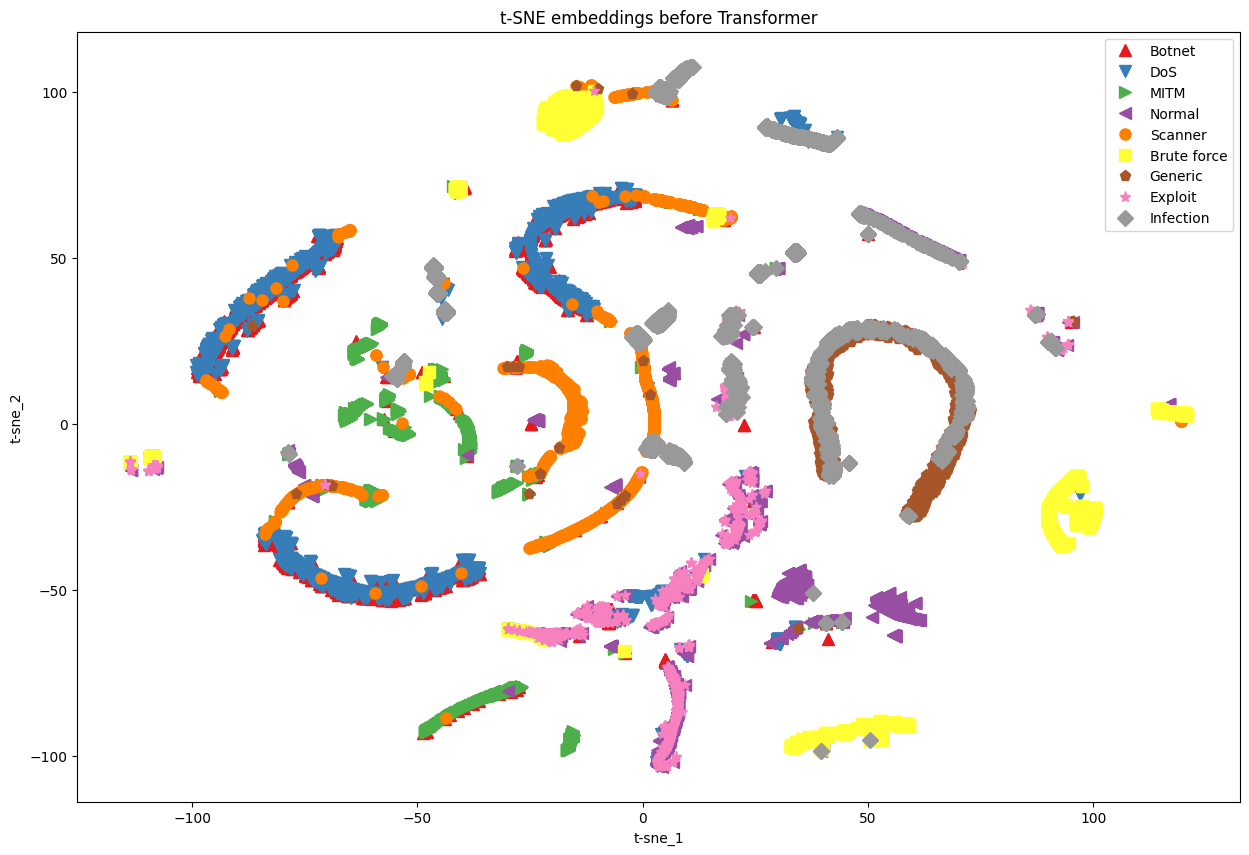

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


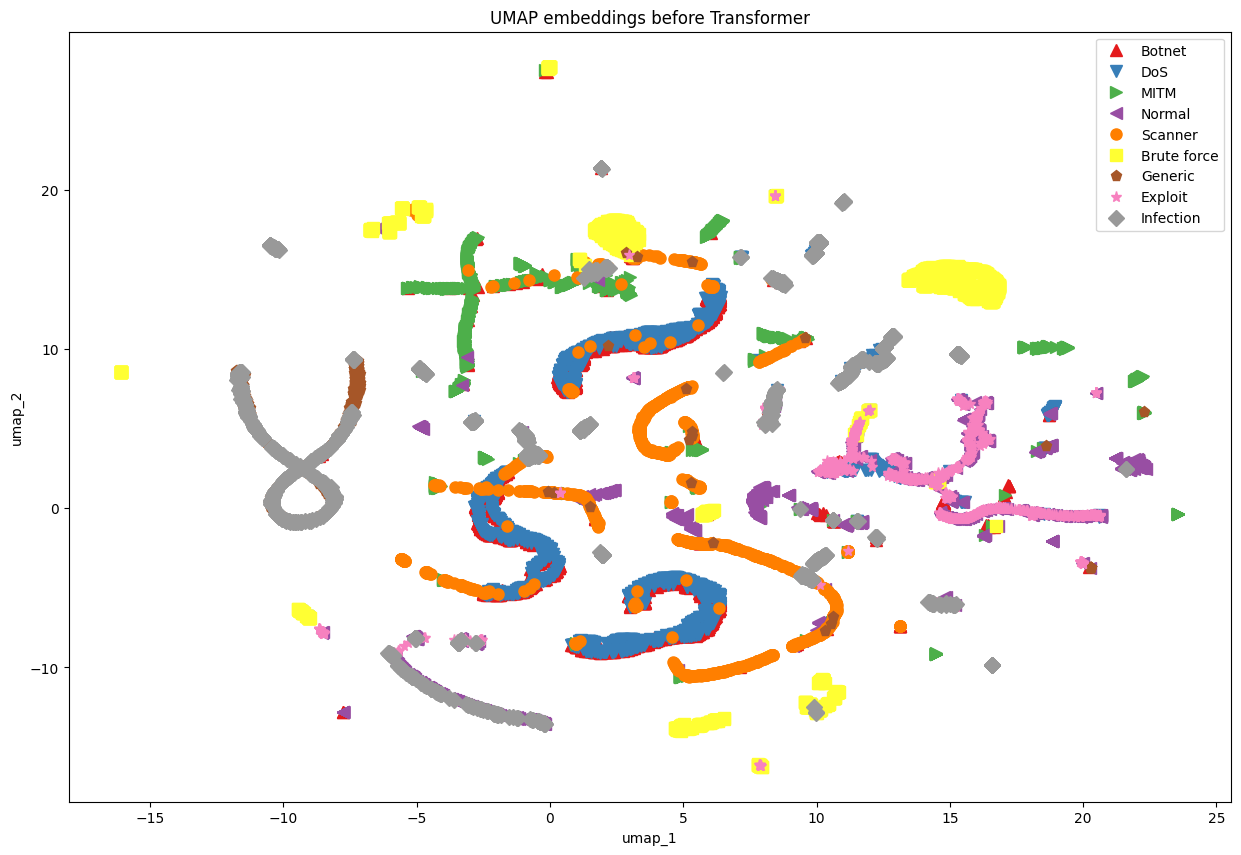

In [ ]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=80, n_jobs=-1, min_dist=0.2)
tsne_reducer = TSNE(n_components=2, perplexity=70, method="barnes_hut", n_jobs=-1, max_iter=2000)

X_test, y_test = test_data.dataset[test_data.indices][0], test_data.dataset[test_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)

def plot_embedding(embedding, y_test, reducer_type="umap", title="plot"):
    import matplotlib as mpl
    colors = mpl.colormaps["Set1"].colors[:n_classes]
    markers = ("^", "v", ">", "<", "o", "s", "p", "*", "D")
    df = pd.DataFrame(embedding, columns=[f"{reducer_type}_1", f"{reducer_type}_2"])
    df["Label"] = y_test
    df.shape
    groups = df.groupby("Label")
    fig = plt.figure(figsize=((15,10)))
    ax = fig.add_subplot()
    for i, group in enumerate(groups):
        name, group_data = group
        ax.plot(group_data[f"{reducer_type}_1"], group_data[f"{reducer_type}_2"], marker=markers[i], 
                color=colors[i], linestyle='', label=category_map[name], markersize=8)
    ax.legend()
    ax.set_xlabel(f"{reducer_type}_1")
    ax.set_ylabel(f"{reducer_type}_2")
    ax.set_title(title)
    plt.show()

plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")


81
KL divergence: 0.3600497543811798


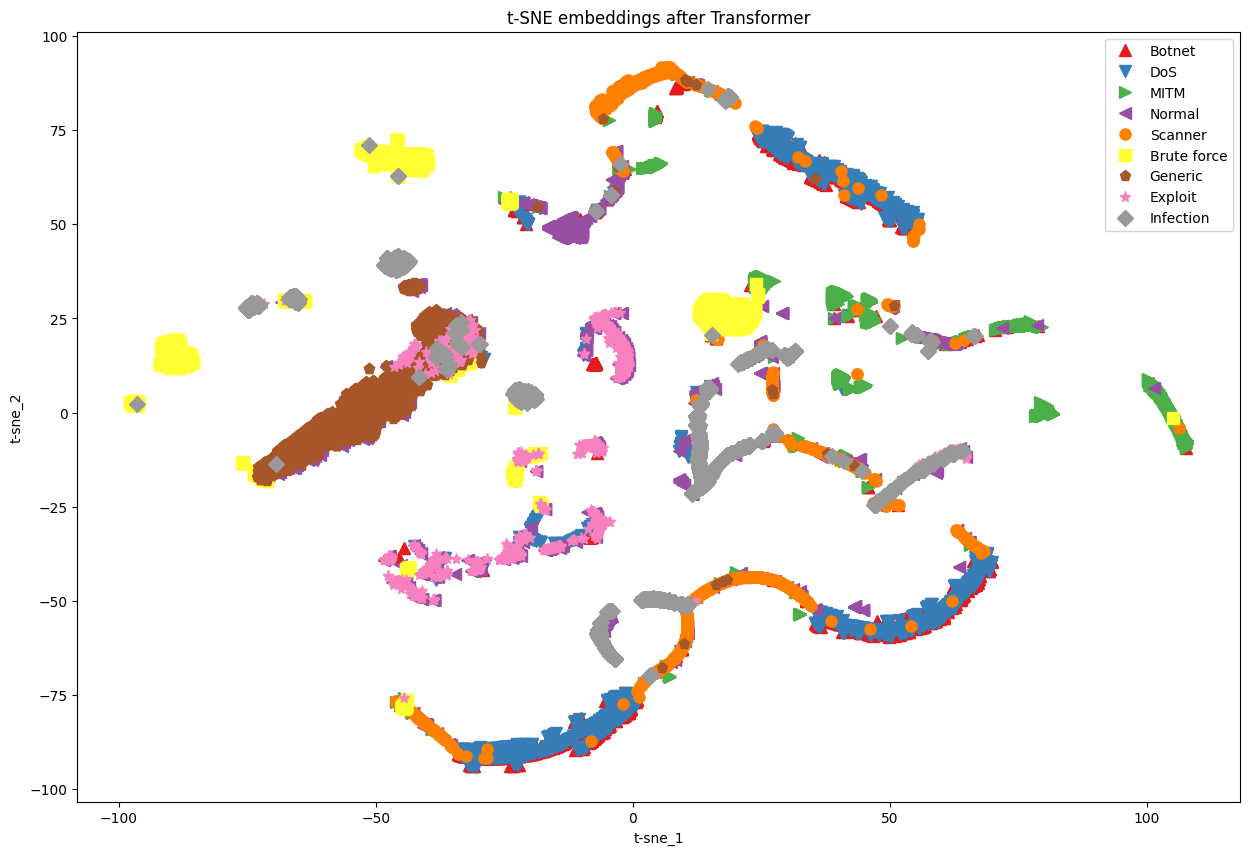

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


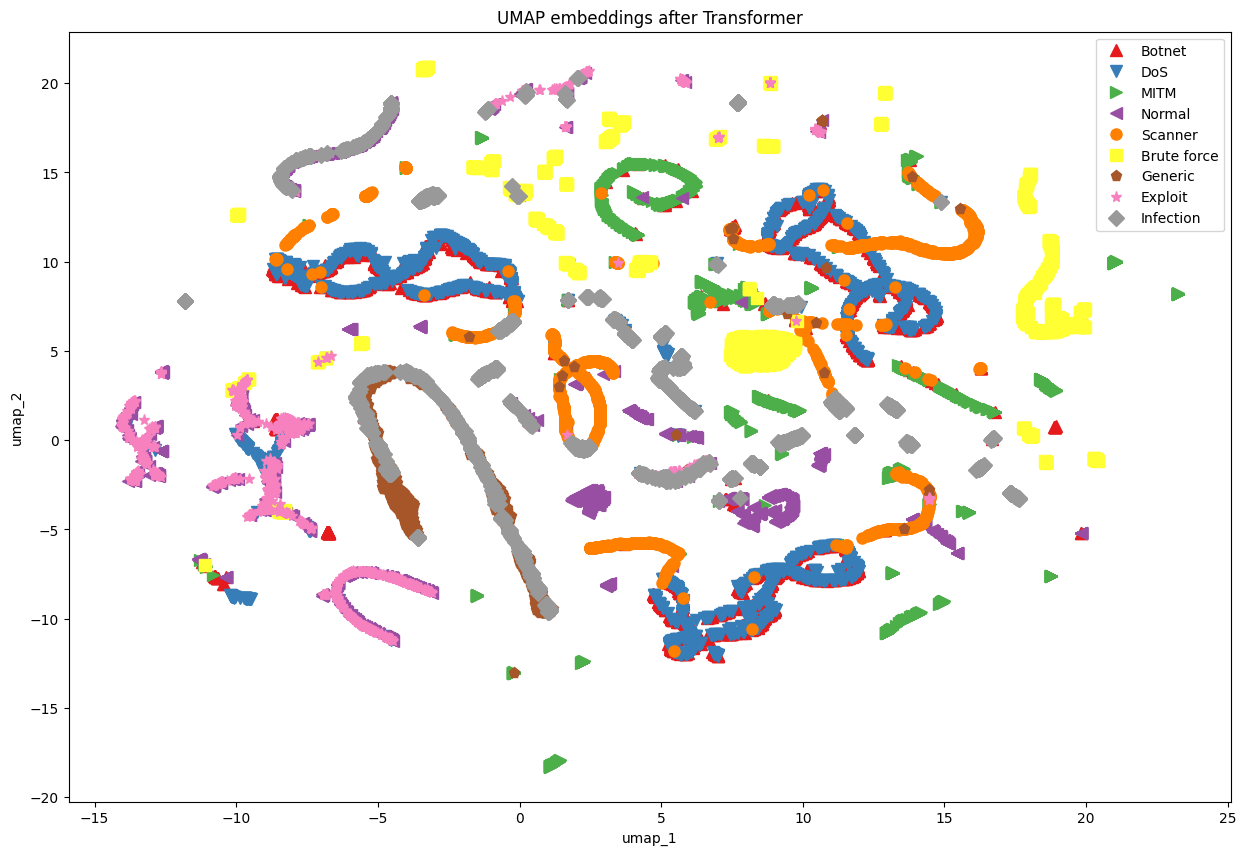

In [57]:
tsne_reducer = TSNE(n_components=2, perplexity=100, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 64), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_data, batch_size=batch_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

**Network specific features removed separatively**

KL divergence: -0.4021585285663605


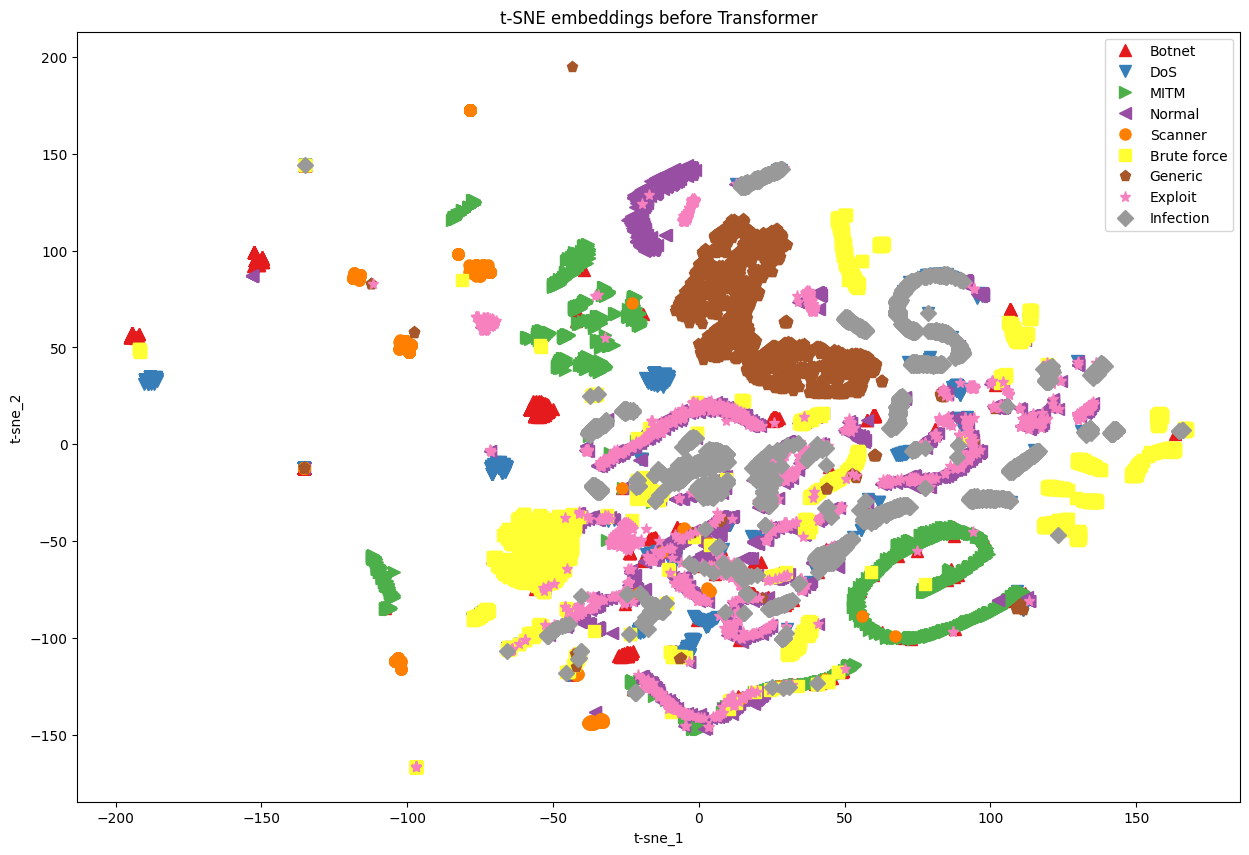

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


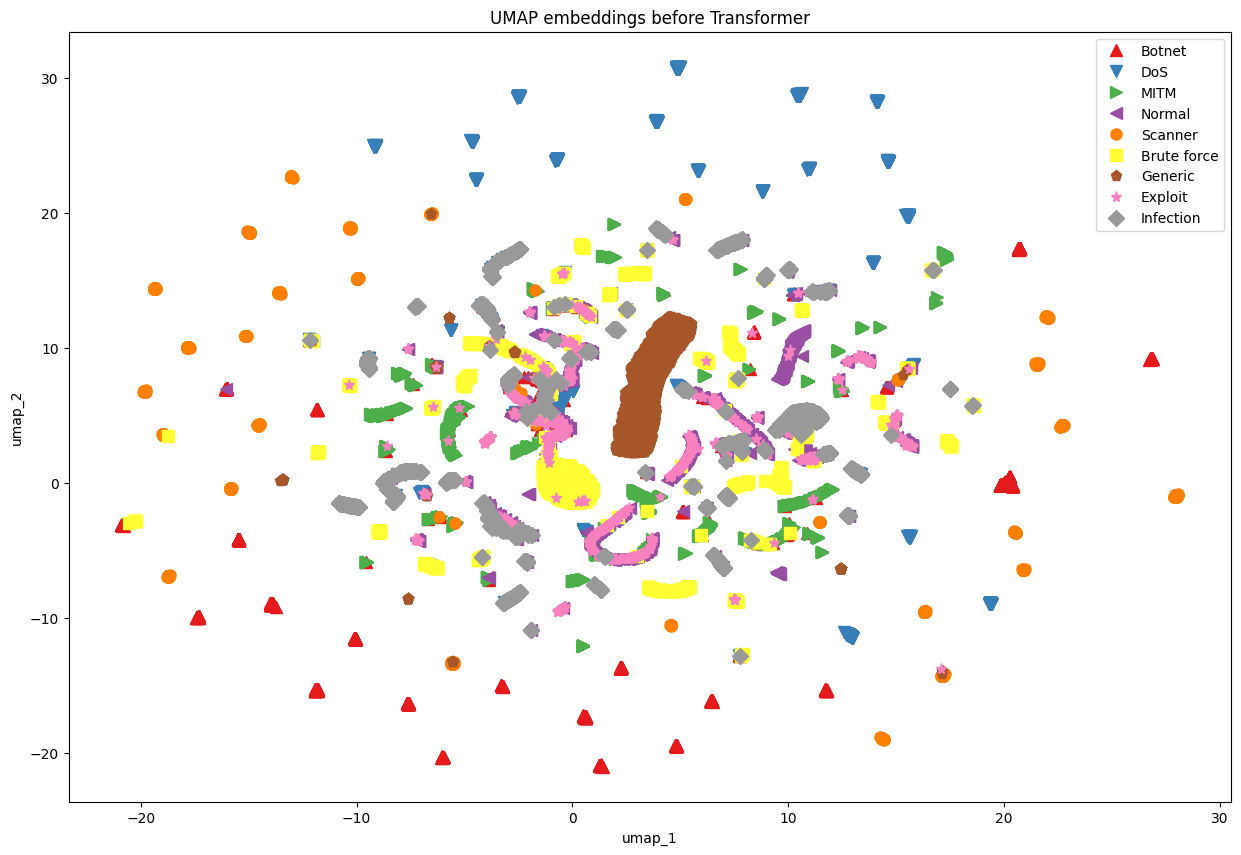

In [64]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_sep_removed_data.dataset[test_sep_removed_data.indices][0], test_sep_removed_data.dataset[test_sep_removed_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")

76
KL divergence: 0.28414952754974365


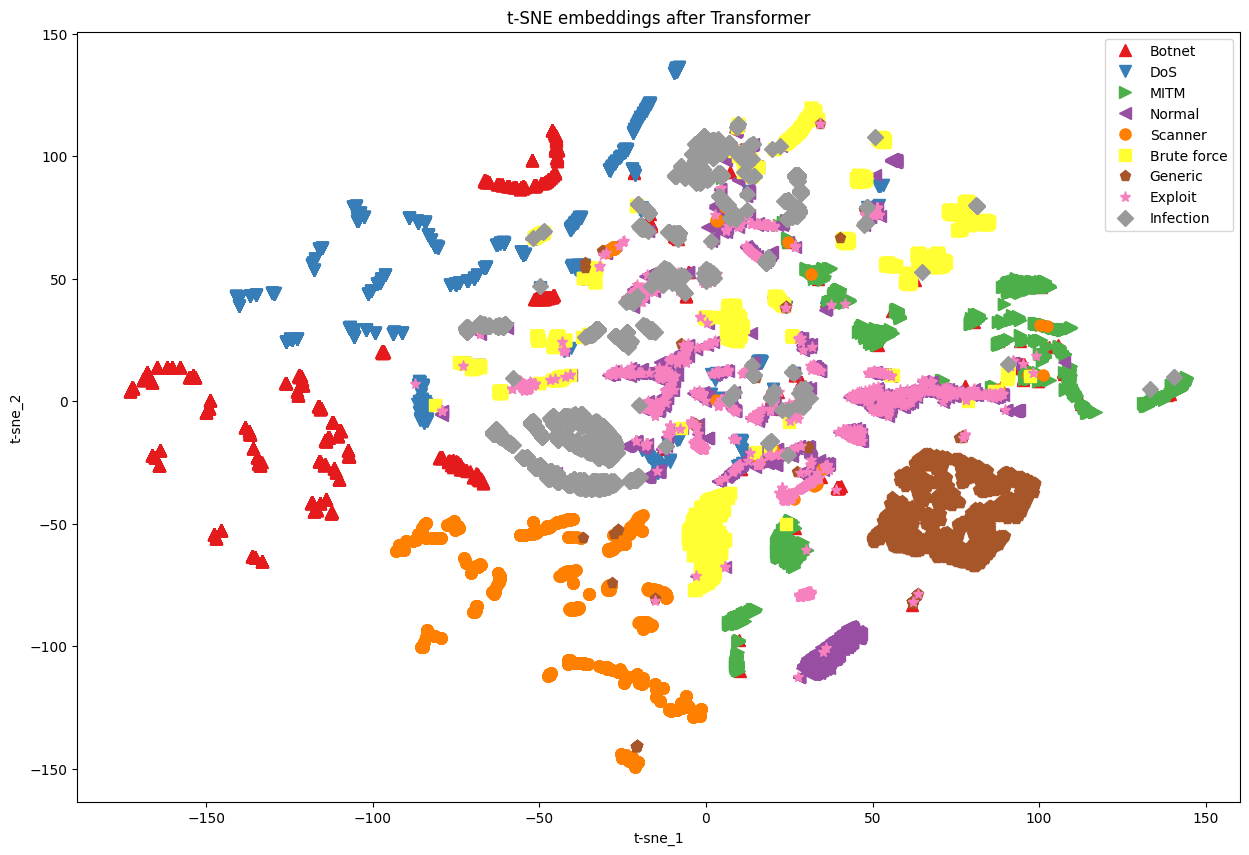

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


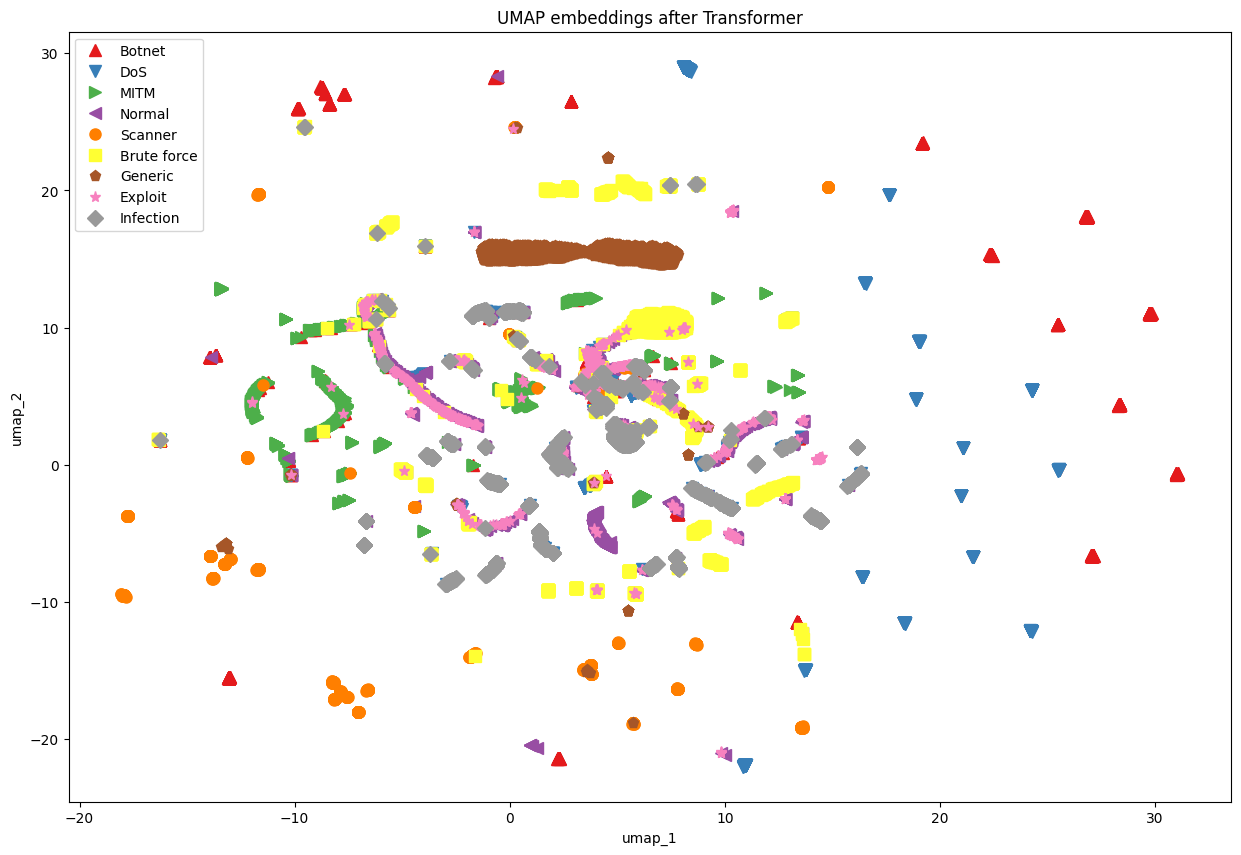

In [67]:
tsne_reducer = TSNE(n_components=2, perplexity=40, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_removed_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_sep_removed_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 128), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_sep_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.1)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

**Unified removed network-specific features**

KL divergence: -0.408961683511734


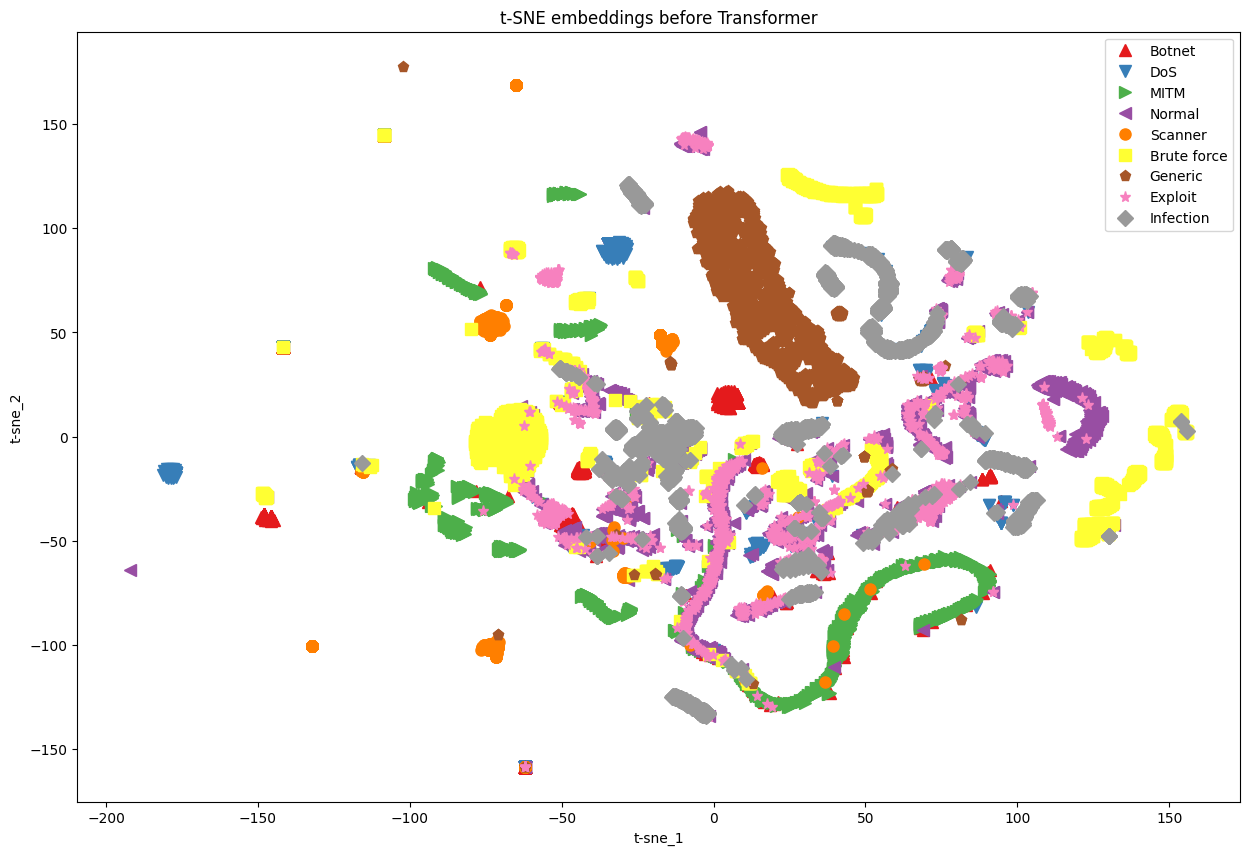

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


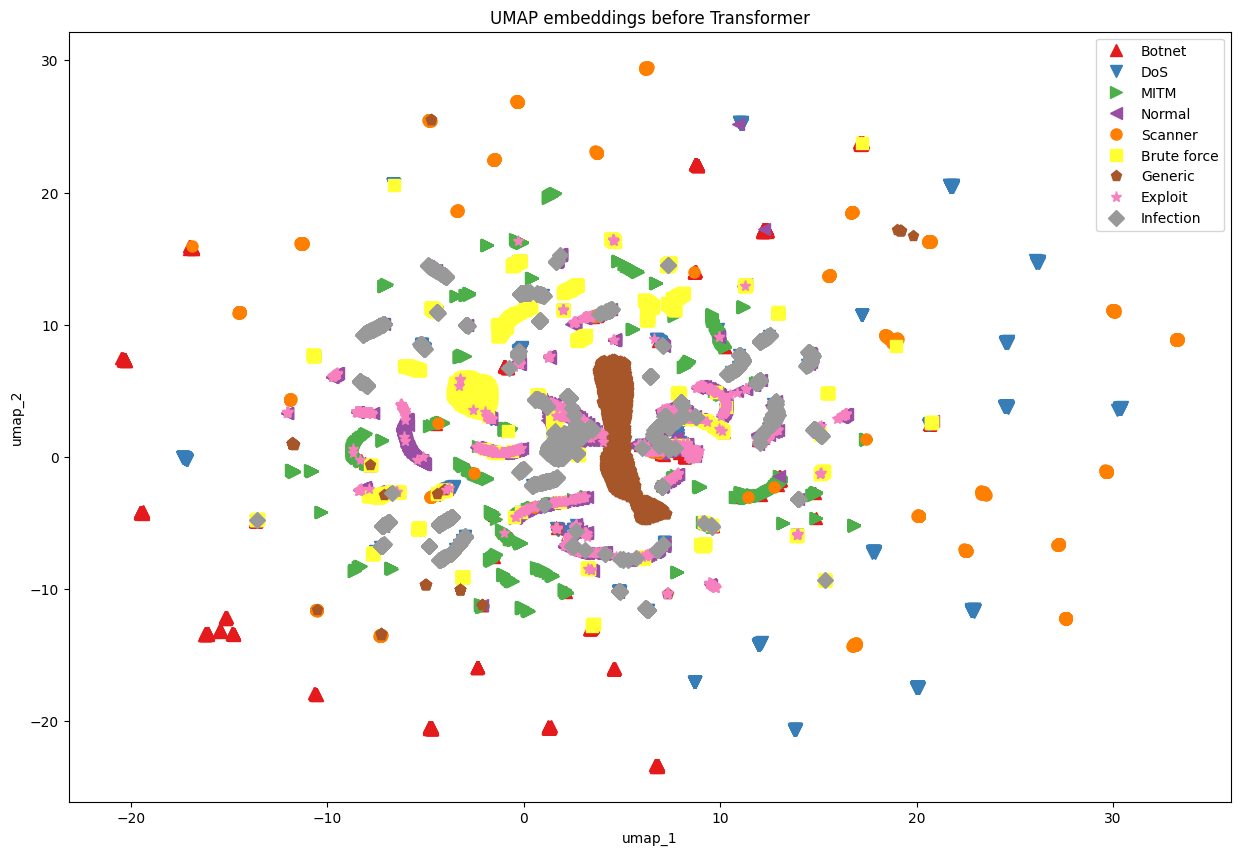

In [70]:
tsne_reducer = TSNE(n_components=2, perplexity=40, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_uni_removed_data.dataset[test_uni_removed_data.indices][0], test_uni_removed_data.dataset[test_uni_removed_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")

74
KL divergence: 0.25508180260658264


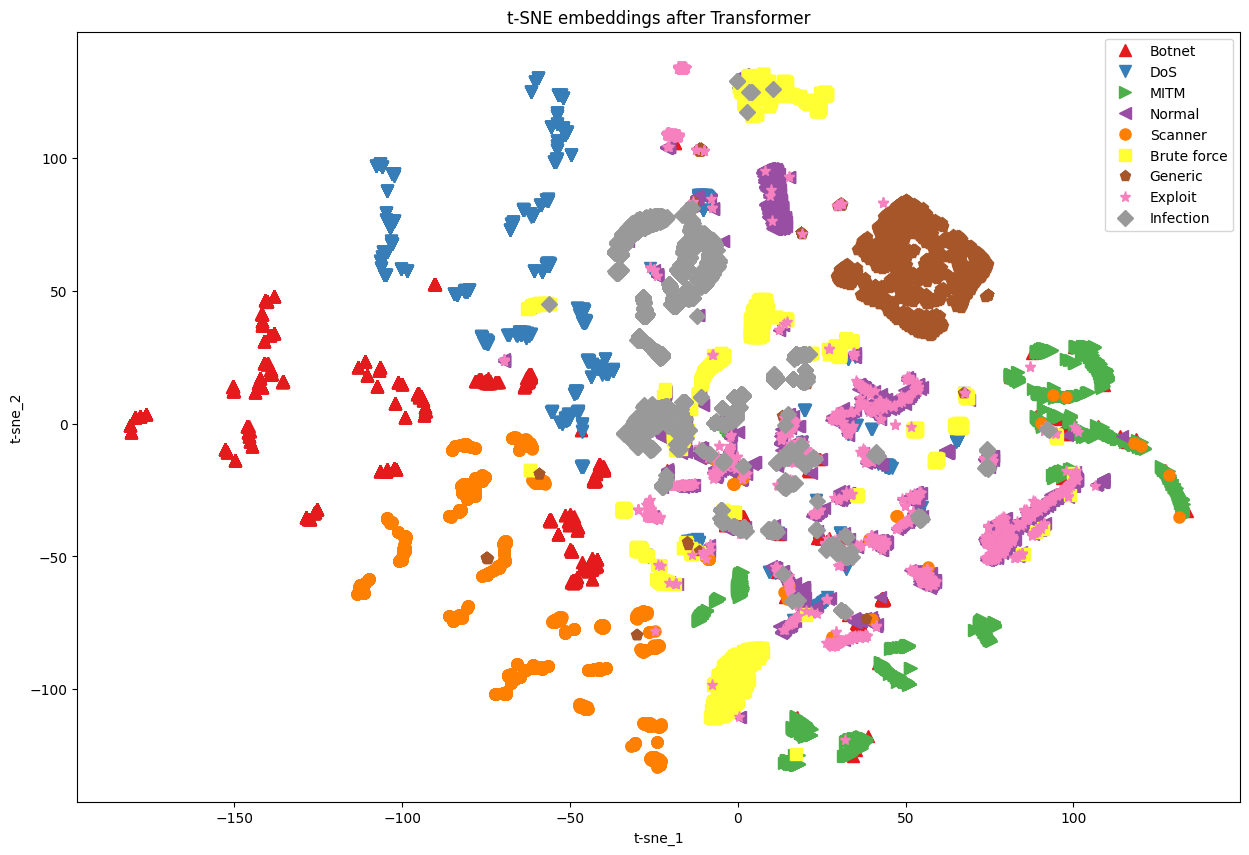

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


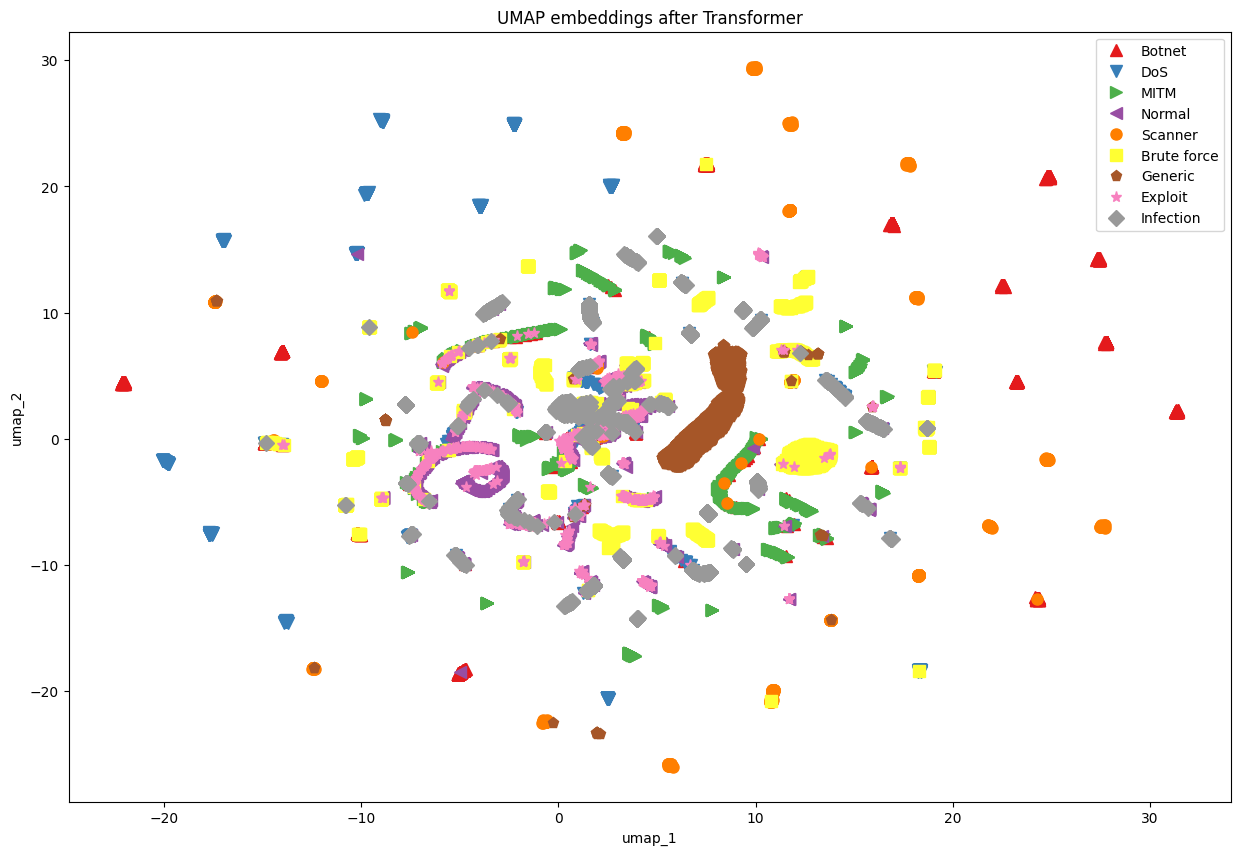

In [71]:
tsne_reducer = TSNE(n_components=2, perplexity=45, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_removed_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_uni_removed_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 128), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_uni_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=40, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

#### LSTM

**LSTM model hyperparameter loading and training**


In [75]:
lstm_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_lstm", "best_config_multiclass.json")
config = load_config(lstm_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
lstm_hyperparameters = config
lstm_hidden_states = config["hidden_lstm_states"]
lstm_model = MyLSTMClassifier(n_classes, **lstm_hyperparameters)

lstm_uni_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_lstm", "improved_removed_features_best_config.json")
config = load_config(lstm_uni_removed_config_file)
learning_uni_removed_rate = config.pop("lr")
batch_uni_removed_size = config.pop("batch_size")
lstm_uni_removed_hyperparameters = config
hidden_lstm_states_uni_removed = config["hidden_lstm_states"]

lstm_sep_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_lstm", "removed_features_best_config_multiclass.json")
config = load_config(lstm_sep_removed_config_file)
learning_sep_removed_rate = config.pop("lr")
batch_sep_removed_size = config.pop("batch_size")
lstm_sep_removed_hyperparameters = config
hidden_lstm_states_sep_removed = config["hidden_lstm_states"]

lstm_sep_removed_model = MyLSTMClassifier(n_classes, **lstm_sep_removed_hyperparameters)
lstm_uni_removed_model = MyLSTMClassifier(n_classes, **lstm_uni_removed_hyperparameters)

# training transformer with all network specific features included
print("TRAINING LSTM WITH ALL NETWORK SPECIFIC FEATURES!")
train_data, test_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_model.to(DEVICE)
ttutils.train_model(lstm_model, lstm_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=LSTM_EPOCHS)
del lstm_model

# training transformer with unified removed network specific 
print("TRAINING LSTM WITH UNIFIED REMOVED NETWORK SPECIFIC FEATURES!")
train_uni_removed_data, test_uni_removed_data = random_split(dataset_unified_removed, [0.9, 0.1])
train_loader = DataLoader(train_uni_removed_data, batch_uni_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_uni_removed_model.to(DEVICE)
ttutils.train_model(lstm_uni_removed_model, lstm_removed_uni_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_uni_removed_rate, epochs=LSTM_EPOCHS)
del lstm_uni_removed_model

# training transformer with all network specific features included
print("TRAINING LSTM WITH SEPARATE REMOVED NETWORK SPECIFIC FEATURES!")
train_sep_removed_data, test_sep_removed_data = random_split(dataset_lstm_removed, [0.9, 0.1])
train_loader = DataLoader(train_sep_removed_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_sep_removed_model.to(DEVICE)
ttutils.train_model(lstm_sep_removed_model, lstm_removed_sep_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_sep_removed_rate, epochs=LSTM_EPOCHS)
del lstm_sep_removed_model

TRAINING LSTM WITH ALL NETWORK SPECIFIC FEATURES!
Epoch 1/10. Average train accuracy: 53.050%, average loss: 1.08506, current loss: 0.55866.
Saved model!
Epoch 2/10. Average train accuracy: 68.687%, average loss: 0.66523, current loss: 0.79368.
Saved model!
Epoch 3/10. Average train accuracy: 74.400%, average loss: 0.54156, current loss: 0.29767.
Saved model!
Epoch 4/10. Average train accuracy: 75.871%, average loss: 0.51177, current loss: 0.22279.
Saved model!
Epoch 5/10. Average train accuracy: 78.370%, average loss: 0.45953, current loss: 0.24211.
Saved model!
Epoch 6/10. Average train accuracy: 79.009%, average loss: 0.43767, current loss: 0.04379.
Saved model!
Epoch 7/10. Average train accuracy: 79.143%, average loss: 0.43174, current loss: 0.39016.
Saved model!
Epoch 8/10. Average train accuracy: 79.316%, average loss: 0.42483, current loss: 0.60407.
Saved model!
Epoch 9/10. Average train accuracy: 79.722%, average loss: 0.41705, current loss: 0.15826.
Saved model!
Epoch 10/10. A